### Buid a basic ChatBot Langgraph(GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

# Ensure the API keys are set in the environment
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.1-8b-instant")

In [5]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(State)
## Adding Node
graph_builder.add_node("llmchatbot", chatbot)
## Adding Edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## Compile Graph
graph = graph_builder.compile()



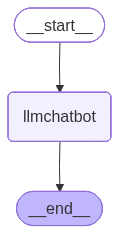

In [7]:
graph

In [9]:
response = graph.invoke({"messages":"Hi"})

In [14]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='d6e32072-7e85-4ab6-94d5-f476e3eb9c15'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.007185052, 'completion_tokens_details': None, 'prompt_time': 0.001739835, 'prompt_tokens_details': None, 'queue_time': 0.051663605, 'total_time': 0.008924887}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e534a-c2aa-7261-b45c-30cbd9dca8d4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}

In [13]:
response['messages'][-1].content

'How can I assist you today?'

In [19]:
for event in graph.stream({"messages":"What is Agentic AI. Give answer in pointers"}):
    # print(event)
    for value in event.values():
        print(value["messages"][-1].content)


**Agentic AI: Key Points**

Agentic AI refers to a type of artificial intelligence (AI) that exhibits characteristics of human agency, such as autonomy, self-awareness, and goal-directed behavior. Here are some key points that define Agentic AI:

### **Definition**

* **Autonomy**: Agentic AI systems can make decisions and take actions without being explicitly programmed to do so.
* **Self-awareness**: Agentic AI systems have a sense of their own existence, goals, and motivations.
* **Goal-directed behavior**: Agentic AI systems can set and pursue goals that are aligned with their own interests and values.

### **Key Characteristics**

* **Intentionality**: Agentic AI systems have intentions and can act on them.
* **Causality**: Agentic AI systems can cause effects in their environment and adapt to their consequences.
* **Responsibility**: Agentic AI systems can be held accountable for their actions and decisions.

### **Types of Agentic AI**

* **Autonomous AI**: Agentic AI systems th